# 🏭 Predictive Maintenance System - Complete ML Pipeline
This notebook contains the **entire comprehensive workflow**, including all Exploratory Data Analysis (EDA), Preprocessing, Feature Engineering, and the training/evaluation of **ALL 6 Machine Learning models** for both Binary and Multi-class classification.


## 1. Import Libraries


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

%matplotlib inline
sns.set_style('whitegrid')


## 2. Data Loading & Initial Inspection


In [2]:
df = pd.read_csv('../data/predictive_maintenance.csv')
print(f'Dataset shape: {df.shape}')
display(df.head())


Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [4]:
print('Missing values:\n', df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())


Missing values:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicates: 0


## 3. Exploratory Data Analysis (EDA)


### 3.1 Target Variable Distribution (Imbalance)


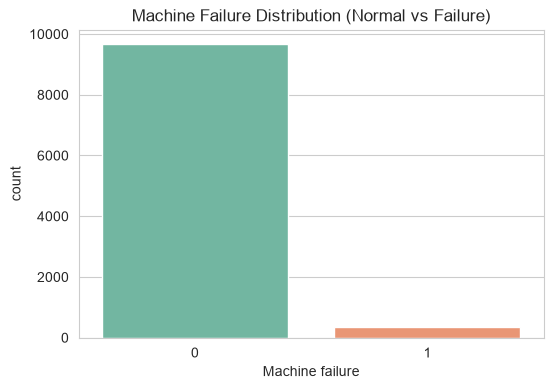

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Machine failure', palette='Set2')
plt.title('Machine Failure Distribution (Normal vs Failure)')
plt.show()
print(df['Machine failure'].value_counts(normalize=True) * 100)


### 3.2 Correlation Heatmap


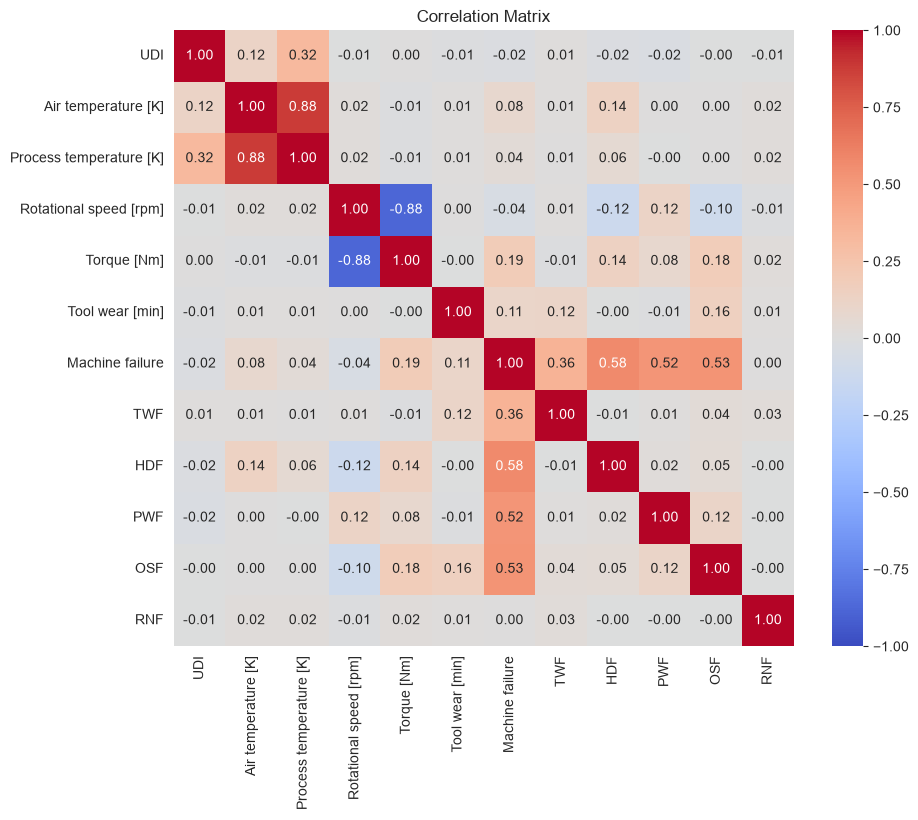

In [6]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()


### 3.3 Feature Distributions by Target


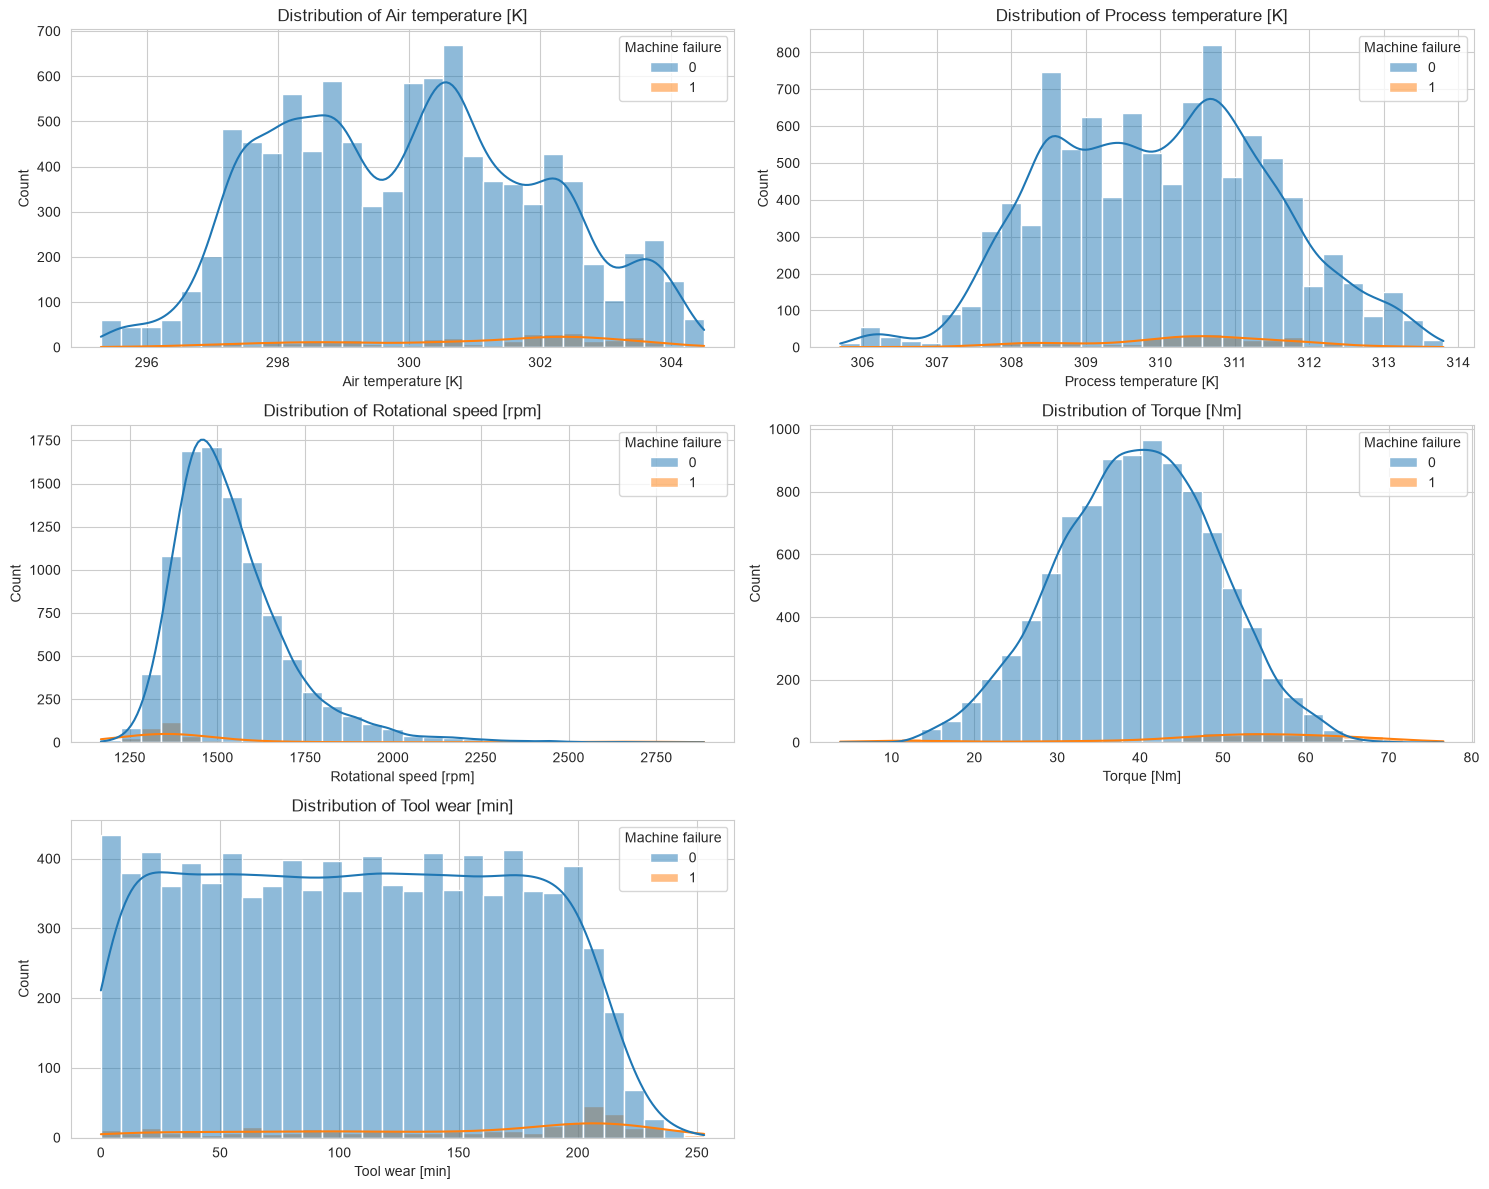

In [21]:
features_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(data=df, x=col, hue='Machine failure', kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}')

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


### 3.4 Torque vs Rotational Speed


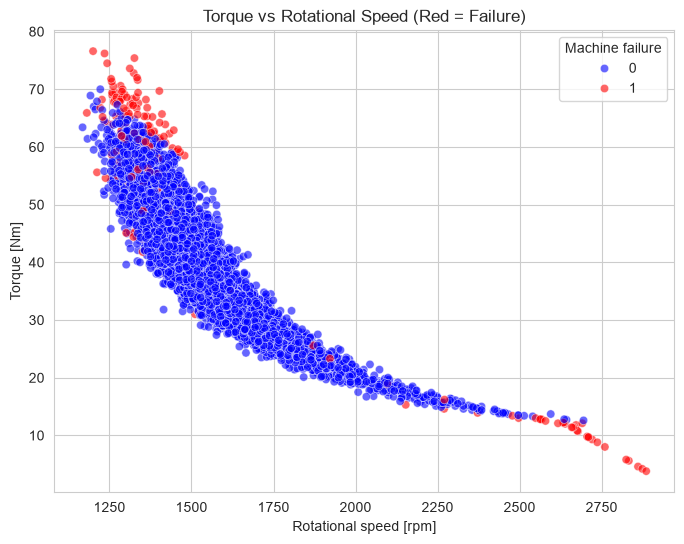

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure', alpha=0.6, palette={0: 'blue', 1: 'red'})
plt.title('Torque vs Rotational Speed (Red = Failure)')
plt.show()


## 4. Data Preprocessing & Feature Engineering


In [9]:
def create_failure_type(row):
    if row['Machine failure'] == 0: return 'No Failure'
    elif row['TWF'] == 1: return 'Tool Wear Failure'
    elif row['HDF'] == 1: return 'Heat Dissipation Failure'
    elif row['PWF'] == 1: return 'Power Failure'
    elif row['OSF'] == 1: return 'Overstrain Failure'
    elif row['RNF'] == 1: return 'Random Failure'
    else: return 'Unknown Failure'

df['Failure Type'] = df.apply(create_failure_type, axis=1)
print('Failure Types:\n', df['Failure Type'].value_counts())


Failure Types:
 Failure Type
No Failure                  9661
Heat Dissipation Failure     115
Power Failure                 91
Overstrain Failure            78
Tool Wear Failure             46
Unknown Failure                9
Name: count, dtype: int64


In [10]:
cols_to_drop = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df = df.drop(columns=cols_to_drop)

type_map = {'L': 0, 'M': 1, 'H': 2}
df['Type'] = df['Type'].map(type_map)


In [22]:
# Feature Engineering
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']
df['torque_per_wear'] = df['Torque [Nm]'] / (df['Tool wear [min]'] + 1)

display(df.head())
df.shape


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Failure Type,temp_diff,power,torque_per_wear
0,1,298.1,308.6,1551,42.8,0,0,No Failure,10.5,66382.8,42.800000
1,0,298.2,308.7,1408,46.3,3,0,No Failure,10.5,65190.4,11.575000
2,0,298.1,308.5,1498,49.4,5,0,No Failure,10.4,74001.2,8.233333
3,0,298.2,308.6,1433,39.5,7,0,No Failure,10.4,56603.5,4.937500
4,0,298.2,308.7,1408,40.0,9,0,No Failure,10.5,56320.0,4.000000


(10000, 11)

## 5. Phase 1: Binary Classification (Fail / No Fail)
training 6 models: Logistic Regression, Decision Tree, Random Forest, XGBoost, SVM, and KNN.


In [23]:
X_bin = df.drop(columns=['Machine failure', 'Failure Type'])
y_bin = df['Machine failure']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

smote = SMOTE(random_state=42)
X_train_b_res, y_train_b_res = smote.fit_resample(X_train_b_scaled, y_train_b)

print(f'Training shape after SMOTE: {X_train_b_res.shape}')


Training shape after SMOTE: (15458, 9)


In [24]:
binary_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}

bin_results = []
bin_trained_models = {}

for name, model in binary_models.items():
    model.fit(X_train_b_res, y_train_b_res)
    y_pred = model.predict(X_test_b_scaled)
    y_proba = model.predict_proba(X_test_b_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    bin_trained_models[name] = model
    bin_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_b, y_pred),
        'Precision': precision_score(y_test_b, y_pred, zero_division=0),
        'Recall': recall_score(y_test_b, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test_b, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test_b, y_proba) if y_proba is not None else np.nan
    })

df_bin_res = pd.DataFrame(bin_results).sort_values('F1-Score', ascending=False)
display(df_bin_res)


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
3,XGBoost,0.9820,0.695122,0.838235,0.760000,0.980286
2,Random Forest,0.9720,0.560000,0.823529,0.666667,0.974957
1,Decision Tree,0.9625,0.470588,0.823529,0.598930,0.895460
4,SVM,0.9250,0.302885,0.926471,0.456522,0.975460
5,KNN,0.9375,0.320755,0.750000,0.449339,0.896789
0,Logistic Regression,0.8660,0.187500,0.882353,0.309278,0.934455


### 5.1 Binary Confusion Matrices


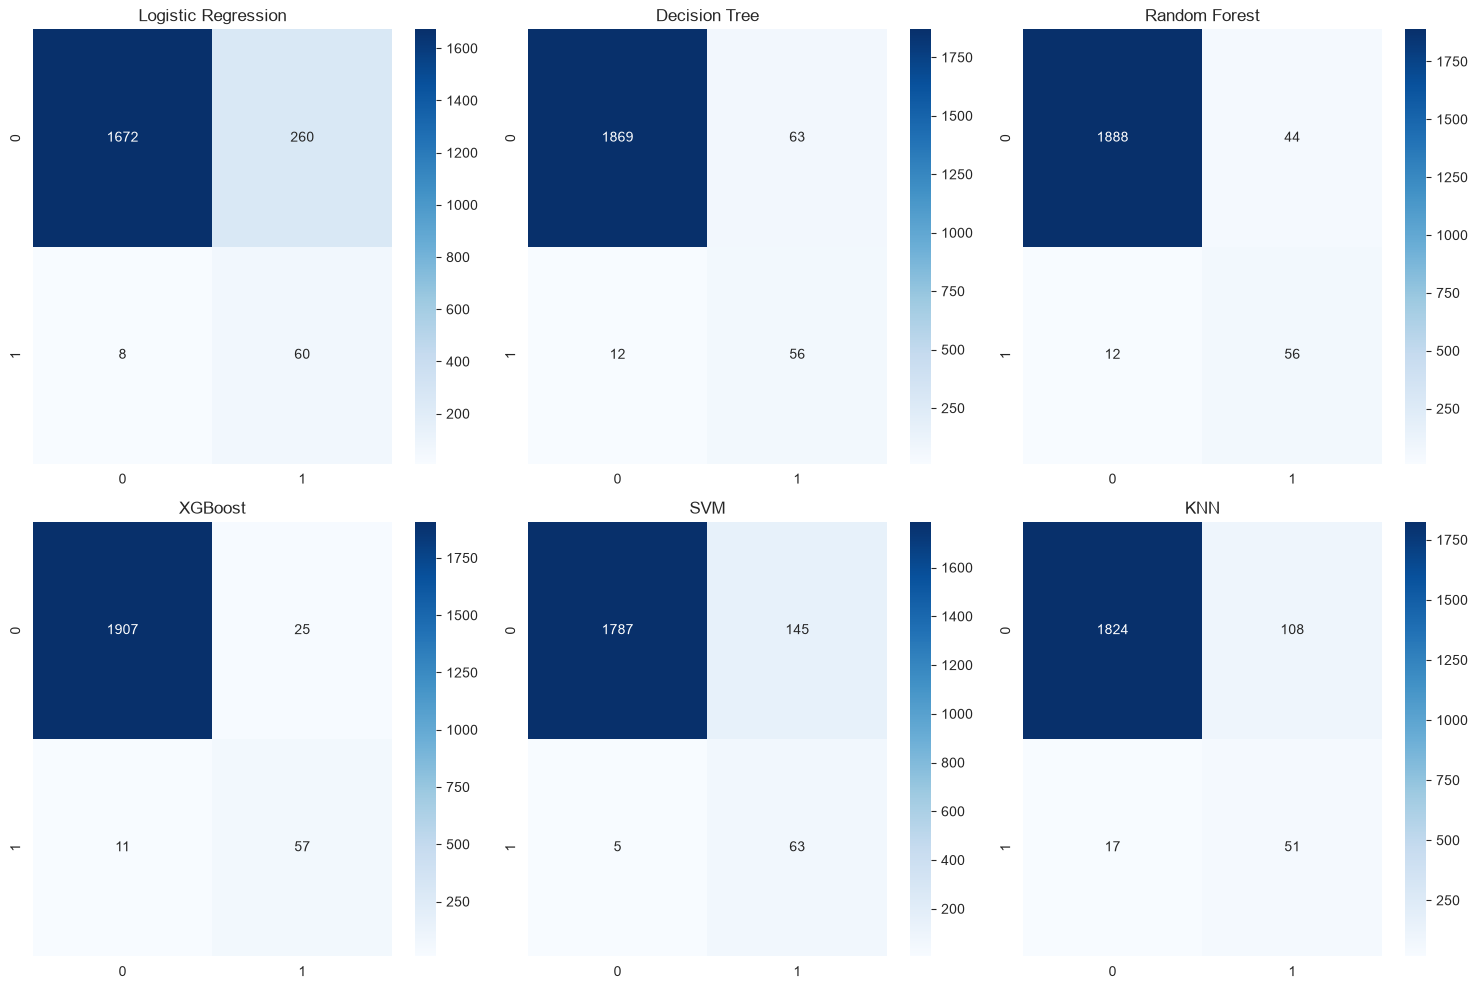

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(bin_trained_models.items()):
    y_pred = model.predict(X_test_b_scaled)
    sns.heatmap(confusion_matrix(y_test_b, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)

plt.tight_layout()
plt.show()


## 6. Phase 2: Multi-class Classification (Failure Type)


In [28]:
le = LabelEncoder()
y_multi = le.fit_transform(df['Failure Type'])

target_names = list(le.classes_)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_bin, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

X_train_m_res, y_train_m_res = smote.fit_resample(X_train_m_scaled, y_train_m)
print(f'Training shape Multi-class after SMOTE: {X_train_m_res.shape}')


Training shape Multi-class after SMOTE: (46374, 9)


In [29]:
multi_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}

multi_results = []
multi_trained_models = {}

for name, model in multi_models.items():
    model.fit(X_train_m_res, y_train_m_res)
    y_pred = model.predict(X_test_m_scaled)
    
    multi_trained_models[name] = model
    multi_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_m, y_pred),
        'Precision (Weighted)': precision_score(y_test_m, y_pred, average='weighted', zero_division=0),
        'Recall (Weighted)': recall_score(y_test_m, y_pred, average='weighted', zero_division=0),
        'F1-Score (Weighted)': f1_score(y_test_m, y_pred, average='weighted', zero_division=0)
    })

df_multi_res = pd.DataFrame(multi_results).sort_values('F1-Score (Weighted)', ascending=False)
display(df_multi_res)


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
3,XGBoost,0.9780,0.987442,0.9780,0.982265
2,Random Forest,0.9745,0.986284,0.9745,0.980050
1,Decision Tree,0.9750,0.984335,0.9750,0.979403
5,KNN,0.9110,0.970962,0.9110,0.937217
4,SVM,0.8540,0.976895,0.8540,0.907102
0,Logistic Regression,0.6110,0.974895,0.6110,0.740988


### 6.1 Multi-class Classification Report (Best Model: XGBoost)


In [18]:
best_multi_model = multi_trained_models['XGBoost']
y_pred_m = best_multi_model.predict(X_test_m_scaled)
print(classification_report(y_test_m, y_pred_m, target_names=[label_mapping[i] for i in range(len(label_mapping))]))


                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00        23
              No Failure       1.00      0.98      0.99      1932
      Overstrain Failure       0.70      1.00      0.82        16
           Power Failure       0.90      1.00      0.95        18
       Tool Wear Failure       0.07      0.22      0.11         9
         Unknown Failure       0.00      0.00      0.00         2

                accuracy                           0.98      2000
               macro avg       0.61      0.70      0.64      2000
            weighted avg       0.99      0.98      0.98      2000



## 7. Feature Importance Analysis


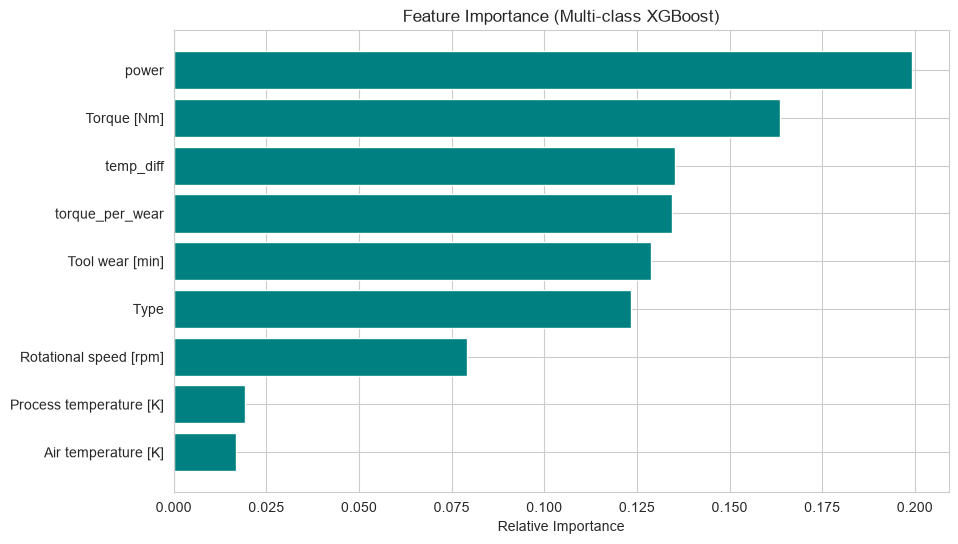

In [19]:
importance = best_multi_model.feature_importances_
indices = np.argsort(importance)
features = X_bin.columns

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importance[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Feature Importance (Multi-class XGBoost)')
plt.xlabel('Relative Importance')
plt.show()
